In [1]:
import pandas as pd
import nfl_data_py as nfl
import matplotlib.pyplot as plt
import numpy as np

import football_functions_public as ff

In [2]:
year = [2024]
df = nfl.import_weekly_data(year,['player_id','headshot_url','player_display_name','position',
      'recent_team', 'season', 'week',
      'completions', 'attempts', 'passing_yards',
       'passing_tds', 'interceptions', 'passing_air_yards', 'passing_yards_after_catch',
      'passing_epa', 'pacr', 
      'carries', 'rushing_yards', 'rushing_tds', 'rushing_epa',
       'receptions', 'targets', 'receiving_yards', 'receiving_tds', 'receiving_air_yards', 'receiving_yards_after_catch',
      'receiving_epa', 'racr', 'target_share', 'air_yards_share', 'wopr', 
       'fantasy_points_ppr'],False)

ngs_pass_df = nfl.import_ngs_data('passing', year)
ngs_rush_df = nfl.import_ngs_data('rushing', year)
ngs_rec_df = nfl.import_ngs_data('receiving', year)

df.rename(columns={"player_display_name": "name"}, inplace = True)
df['name'] = ff.fixname(df['name'])
ID_dict = df[['name', 'player_id']].drop_duplicates().set_index('name').to_dict()['player_id']
headshot_dict = df[['name', 'headshot_url']].drop_duplicates().set_index('name').to_dict()['headshot_url']

In [3]:
Week = 15
pff_receiving = pd.read_csv("D:/OneDrive/Documents/Python Scripts/football/PFF/2024/Receiving/Week "+str(Week)+".csv")
pff_receiving['player'] = ff.fixname(pff_receiving['player'])
pff_passing = pd.read_csv("D:/OneDrive/Documents/Python Scripts/football/PFF/2024/Passing/Week "+str(Week)+".csv")
pff_passing['player'] = ff.fixname(pff_passing['player'])
pff_passing['team_name'] = ff.fixteamname(pff_passing['team_name'])

(Week_summary, Week_QB_summary, Week_WR_summary, Week_TE_summary, 
 Week_RB_summary, Week_QBs_df, Week_WRs_df, Week_TEs_df, Week_RBs_df) = ff.weekly_recap(Week, df, ID_dict, pff_receiving, pff_passing)

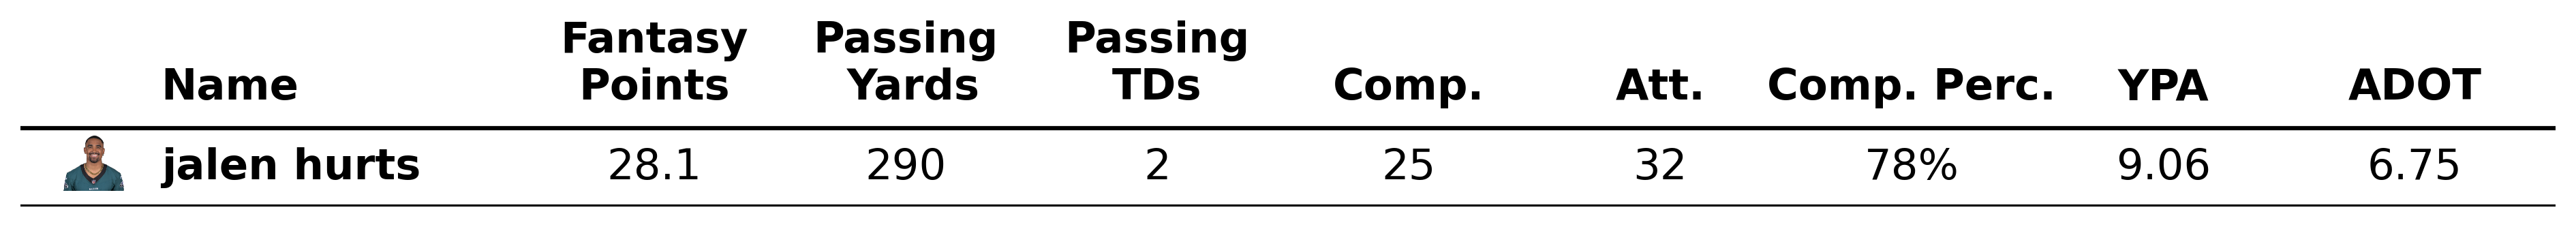

In [4]:
team =  'PHI'
save = 0

ff.plot_pass_recap(team,Week,Week_summary[team],headshot_dict,save)

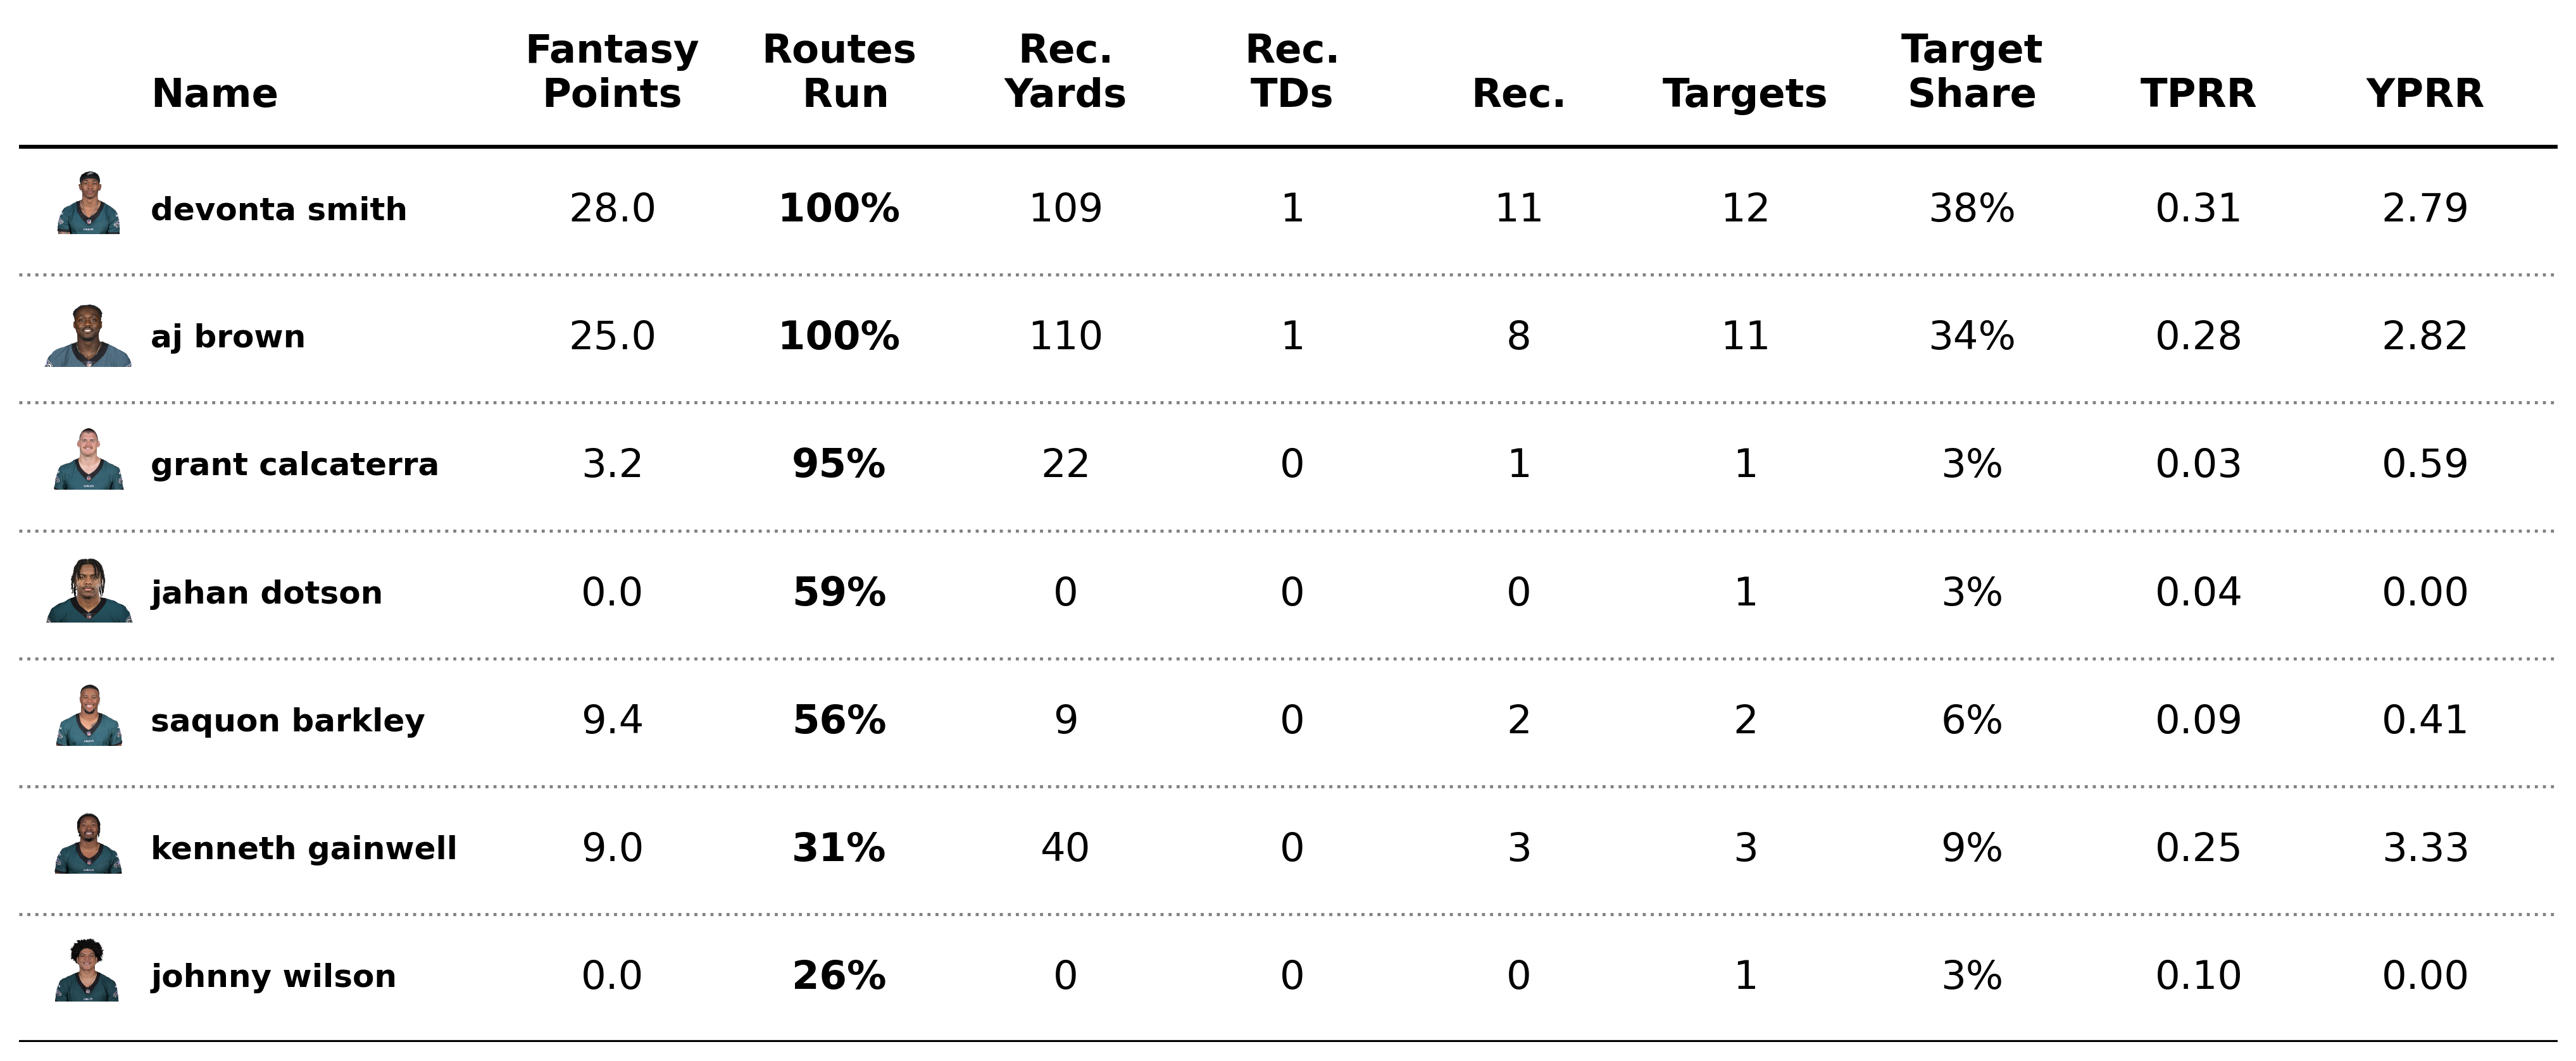

In [5]:
ff.plot_rec_recap(team,Week,Week_summary[team],headshot_dict,save)

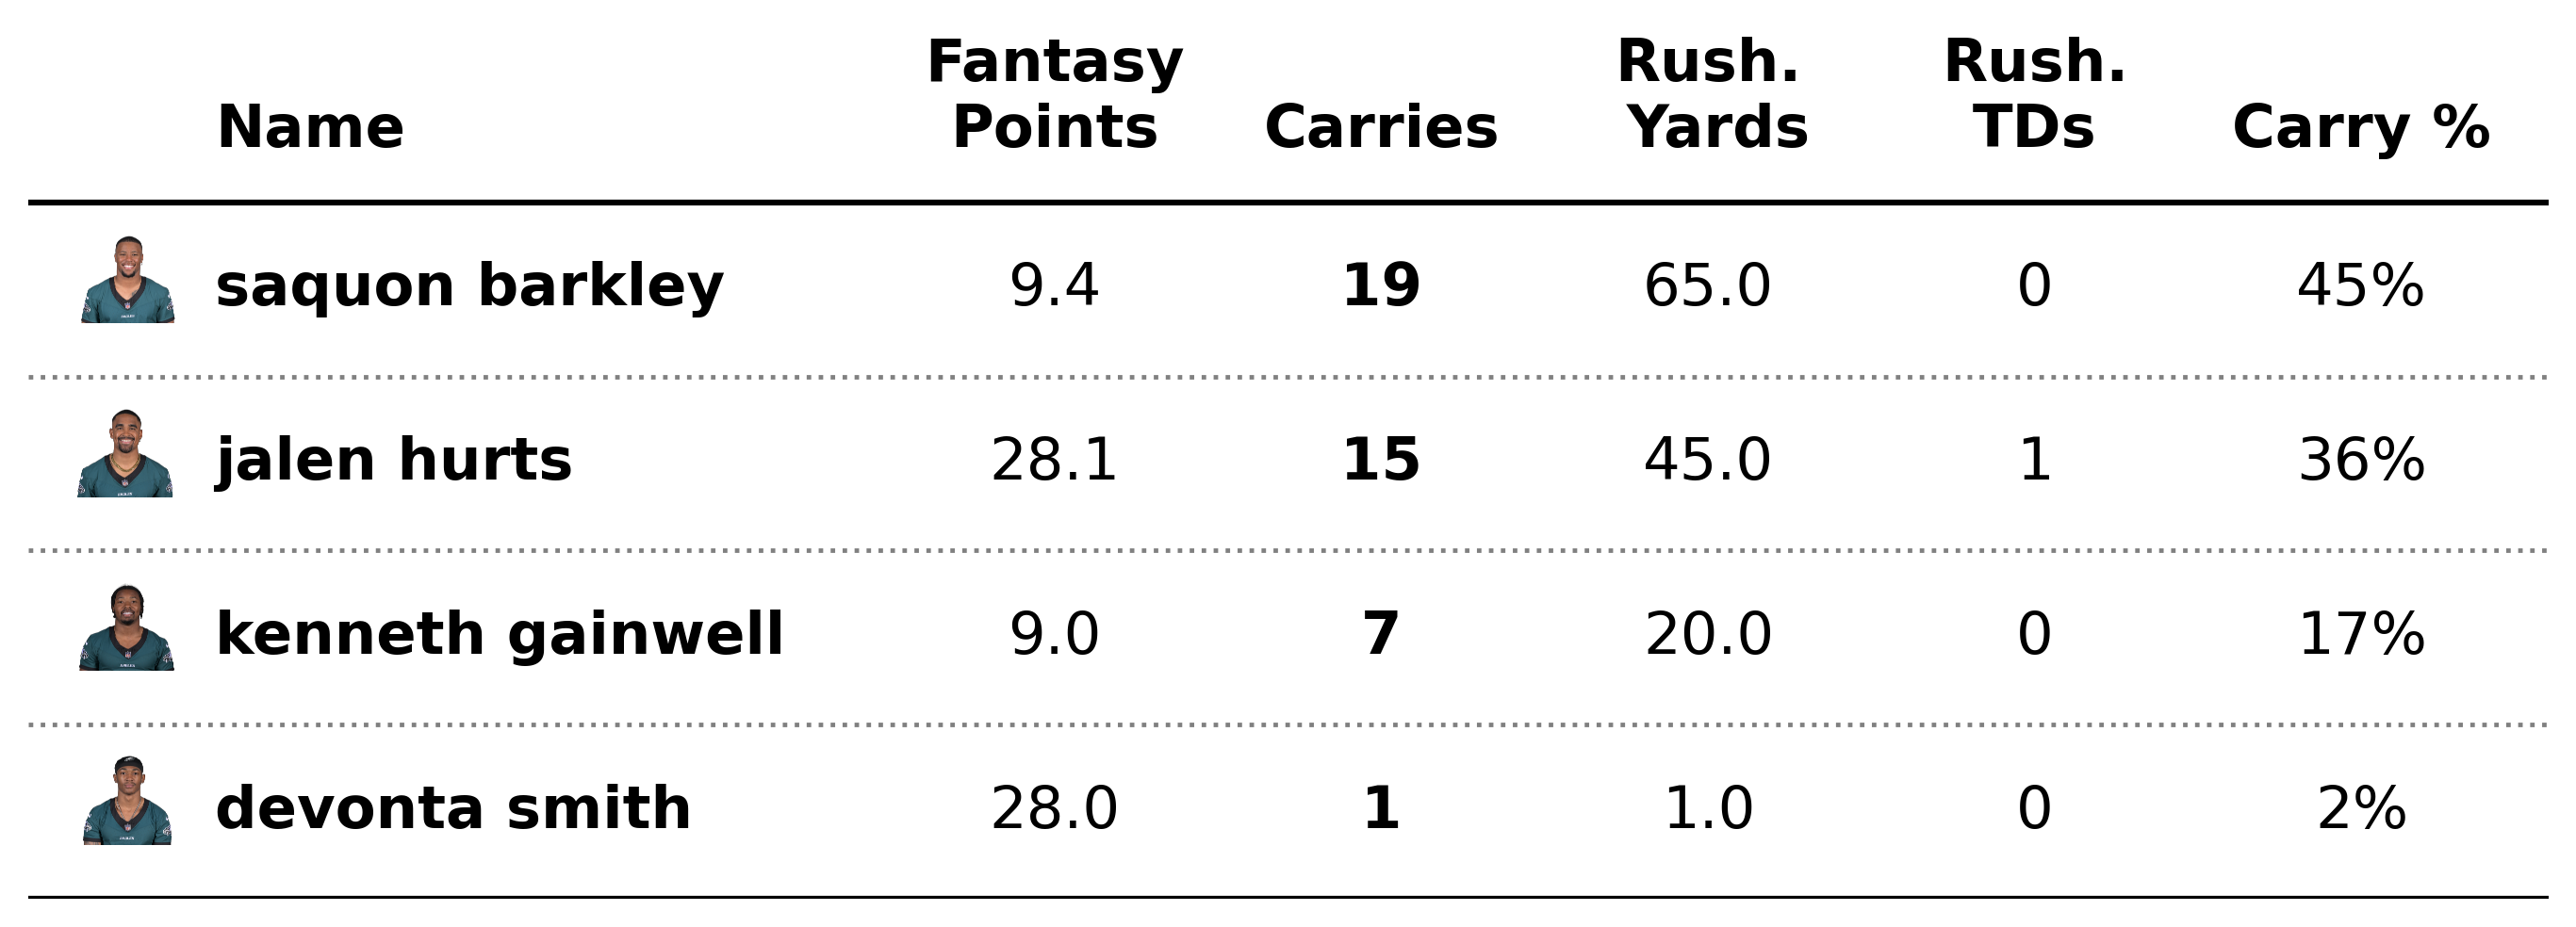

In [6]:
ff.plot_rush_recap(team,Week,Week_summary[team],headshot_dict,save)